In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import log1p

from pyspark.ml.feature import VectorAssembler, MinMaxScaler

from pyspark.ml.regression import (
    LinearRegression,
    DecisionTreeRegressor,
    RandomForestRegressor,
    GBTRegressor
)

from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HousePricePrediction") \
    .getOrCreate()

print("Spark OK")

Spark OK


## Bài toán 1: Xây dựng Model dự đoán giá nhà

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df = spark.read.csv(
    "/content/drive/MyDrive/đồ án /clean_data.csv",
    header=True,
    inferSchema=True
)

df.show(5)
df.printSchema()

+-------+---------+---------+---------------+------------+----------------+------------+-------------------+--------+-----------+---------+-------------+----------------+
|gia_ban|dien_tich|loai_hinh|giay_to_phap_ly|so_phong_ngu|so_phong_ve_sinh|tong_so_tang|tinh_trang_noi_that|dac_diem|chieu_ngang|chieu_dai|e_Quận Gò Vấp|e_Quận Phú Nhuận|
+-------+---------+---------+---------------+------------+----------------+------------+-------------------+--------+-----------+---------+-------------+----------------+
|   3.85|     36.0|        0|              5|         2.0|             2.0|         2.0|                  3|       6|        4.5|      8.0|          0.0|             0.0|
|   9.79|     62.0|        0|              1|         4.0|             3.0|         3.0|                  1|       2|        4.0|     12.0|          0.0|             0.0|
|    7.2|     54.0|        0|              5|         3.0|             2.0|         2.0|                  2|       7|        7.0|      7.7|      

##Linear Regression
## Decision Tree
## Random Forest Regressor
## Gradient Boosted Tree

In [5]:
# ===== 1. Import =====
from pyspark.sql.functions import log1p
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd

# ===== 2. Log transform target =====
df = df.withColumn("label", log1p("gia_ban"))

# ===== 3. Feature vector =====
feature_cols = [
    "dien_tich","loai_hinh","giay_to_phap_ly","so_phong_ngu","so_phong_ve_sinh",
    "tong_so_tang","tinh_trang_noi_that","dac_diem","chieu_ngang","chieu_dai",
    "e_Quận Gò Vấp","e_Quận Phú Nhuận"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df = assembler.transform(df)

# ===== 4. Train/Test split =====
train_df, test_df = df.randomSplit([0.8,0.2], seed=42)
train_df = train_df.cache()
test_df = test_df.cache()

# ===== 5. Scaling (cho Linear Regression) =====
scaler = MinMaxScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(train_df)
train_scaled = scaler_model.transform(train_df)
test_scaled = scaler_model.transform(test_df)

# ===== 6. Train models =====
lr = LinearRegression(featuresCol="scaled_features", labelCol="label").fit(train_scaled)
dt = DecisionTreeRegressor(featuresCol="features", labelCol="label", maxDepth=10).fit(train_df)
rf = RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=100, maxDepth=10, seed=42).fit(train_df)
gbt = GBTRegressor(featuresCol="features", labelCol="label", maxIter=80, maxDepth=5).fit(train_df)

lr_pred = lr.transform(test_scaled)
dt_pred = dt.transform(test_df)
rf_pred = rf.transform(test_df)
gbt_pred = gbt.transform(test_df)

# ===== 7. Evaluation =====
rmse_eval = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
mae_eval = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
r2_eval = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosted Tree": gbt_pred
}

results = []
for name, pred in models.items():
    results.append({
        "Model": name,
        "RMSE": rmse_eval.evaluate(pred),
        "MAE": mae_eval.evaluate(pred),
        "R2": r2_eval.evaluate(pred)
    })

pd.DataFrame(results).sort_values("R2", ascending=False)

,Model,RMSE,MAE,R2
2,Random Forest,0.200285,0.137304,0.816822
3,Gradient Boosted Tree,0.204404,0.140925,0.809210
1,Decision Tree,0.231565,0.153916,0.755138
0,Linear Regression,0.247553,0.177218,0.720159


Kết quả thực nghiệm cho thấy mô hình Random Forest Regressor đạt hiệu suất tốt nhất với hệ số xác định
𝑅
2
=
0.8168
R
2
=0.8168, thấp nhất về RMSE và MAE. Điều này cho thấy Random Forest có khả năng mô hình hóa tốt mối quan hệ phi tuyến giữa các đặc trưng của bất động sản và giá bán nhà.

Gradient Boosted Tree cũng cho kết quả tốt với
𝑅
2
=
0.809
R
2
=0.809, tuy nhiên vẫn thấp hơn Random Forest một chút. Trong khi đó, Decision Tree và Linear Regression cho hiệu suất thấp hơn do hạn chế về khả năng học các quan hệ phức tạp trong dữ liệu.

### Bài toán 2: Phát hiện giá bất thường (Anomaly Detection)


In [6]:
#Tính sai số dự đoán
from pyspark.sql.functions import abs, col

rf_anomaly = rf_pred.withColumn(
    "error",
    abs(col("label") - col("prediction"))
)

rf_anomaly.select("gia_ban","prediction","error").show(5)

+-------+------------------+-------------------+
|gia_ban|        prediction|              error|
+-------+------------------+-------------------+
|   0.82|1.0358554940564537| 0.4370189929677497|
|  0.968|0.9696706291517613|0.29265283052169966|
|    1.1| 1.084190760015315|0.34225341528593756|
|   1.25|1.2048578394173715| 0.3939276232010427|
|    1.3|1.3252536541322493| 0.4923445311971453|
+-------+------------------+-------------------+
only showing top 5 rows


In [7]:
#Xác định ngưỡng anomaly
threshold = rf_anomaly.approxQuantile("error",[0.95],0.01)[0]

threshold

0.3873719746587687

In [8]:
#Đánh dấu nhà bất thường
rf_anomaly = rf_anomaly.withColumn(
    "anomaly",
    (col("error") > threshold).cast("int")
)

In [9]:
#Xem các nhà bất thường
rf_anomaly.filter("anomaly = 1") \
.select("gia_ban","prediction","error","dien_tich","so_phong_ngu") \
.show(20)

+-------+------------------+-------------------+---------+------------+
|gia_ban|        prediction|              error|dien_tich|so_phong_ngu|
+-------+------------------+-------------------+---------+------------+
|   0.82|1.0358554940564537| 0.4370189929677497|     10.0|         1.0|
|   1.25|1.2048578394173715| 0.3939276232010427|     12.0|         1.0|
|    1.3|1.3252536541322493| 0.4923445311971453|     22.0|         1.0|
|    1.6|1.3979559039621798| 0.4424444589347434|     20.0|         2.0|
|   1.75| 1.655059632497312|  0.643458720818832|     36.0|         1.0|
|    1.8|1.4339657461658049| 0.4043463289846465|     20.5|         2.0|
|   1.98|1.6028243392132802| 0.5109010386959671|     32.0|         2.0|
|    2.3|1.6440020378470146|0.45007956937458005|     26.0|         1.0|
|   2.55|1.6925829144468687| 0.4256353109595443|     36.0|         2.0|
|   2.75|1.8946879039321523| 0.5729320639498328|     20.0|        10.0|
|   2.85|1.8178084913516985| 0.4697353430520057|     36.0|      

In [10]:
#Đếm số nhà bất thường
rf_anomaly.groupBy("anomaly").count().show()

+-------+-----+
|anomaly|count|
+-------+-----+
|      1|   94|
|      0| 1487|
+-------+-----+



In [11]:
from pyspark.sql.functions import col, mean, stddev, abs

# tạo dataframe kết quả
df_res = df

# tính mean và std
stats = df_res.select(
    mean("gia_ban").alias("mean"),
    stddev("gia_ban").alias("std")
).collect()[0]

mean_price = stats["mean"]
std_price = stats["std"]

# tính z-score
df_res = df_res.withColumn(
    "z_score",
    (col("gia_ban") - mean_price) / std_price
)

# đánh dấu bất thường
df_res = df_res.withColumn(
    "anomaly_zscore",
    abs(col("z_score")) > 3
)

In [12]:
#Min / Max Rule
df_res = df_res.withColumn(
    "price_m2",
    col("gia_ban") / col("dien_tich")
)

df_res = df_res.withColumn(
    "anomaly_minmax",
    (col("price_m2") < 30) | (col("price_m2") > 500)
)

In [13]:
#Percentile (P10 – P90)
p10, p90 = df_res.approxQuantile(
    "price_m2",
    [0.1, 0.9],
    0.01
)

df_res = df_res.withColumn(
    "anomaly_percentile",
    (col("price_m2") < p10) | (col("price_m2") > p90)
)

In [14]:
df_res.selectExpr(
    "sum(cast(anomaly_zscore as int)) as anomaly_zscore",
    "sum(cast(anomaly_minmax as int)) as anomaly_minmax",
    "sum(cast(anomaly_percentile as int)) as anomaly_percentile"
).show()

+--------------+--------------+------------------+
|anomaly_zscore|anomaly_minmax|anomaly_percentile|
+--------------+--------------+------------------+
|            40|          8273|              1715|
+--------------+--------------+------------------+



In [15]:
rf_count = rf_anomaly.filter("anomaly = 1").count()

print("Prediction error (Random Forest):", rf_count)

Prediction error (Random Forest): 94


In [16]:
import pandas as pd

z = df_res.filter("anomaly_zscore = true").count()
mm = df_res.filter("anomaly_minmax = true").count()
pc = df_res.filter("anomaly_percentile = true").count()
rf = rf_anomaly.filter("anomaly = 1").count()

pd.DataFrame({
    "Method":[
        "Z-score",
        "MinMax rule",
        "Percentile",
        "Prediction error (Random Forest)"
    ],
    "Houses detected":[z,mm,pc,rf]
})

,Method,Houses detected
0,Z-score,40
1,MinMax rule,8273
2,Percentile,1715
3,Prediction error (Random Forest),94


In [17]:
pdf = df_res.select(
    "dien_tich",
    "price_m2",
    "anomaly_zscore",
    "anomaly_minmax",
    "anomaly_percentile"
).toPandas()

pdf_rf = rf_anomaly.select(
    "prediction",
    "error",
    "anomaly"
).toPandas()

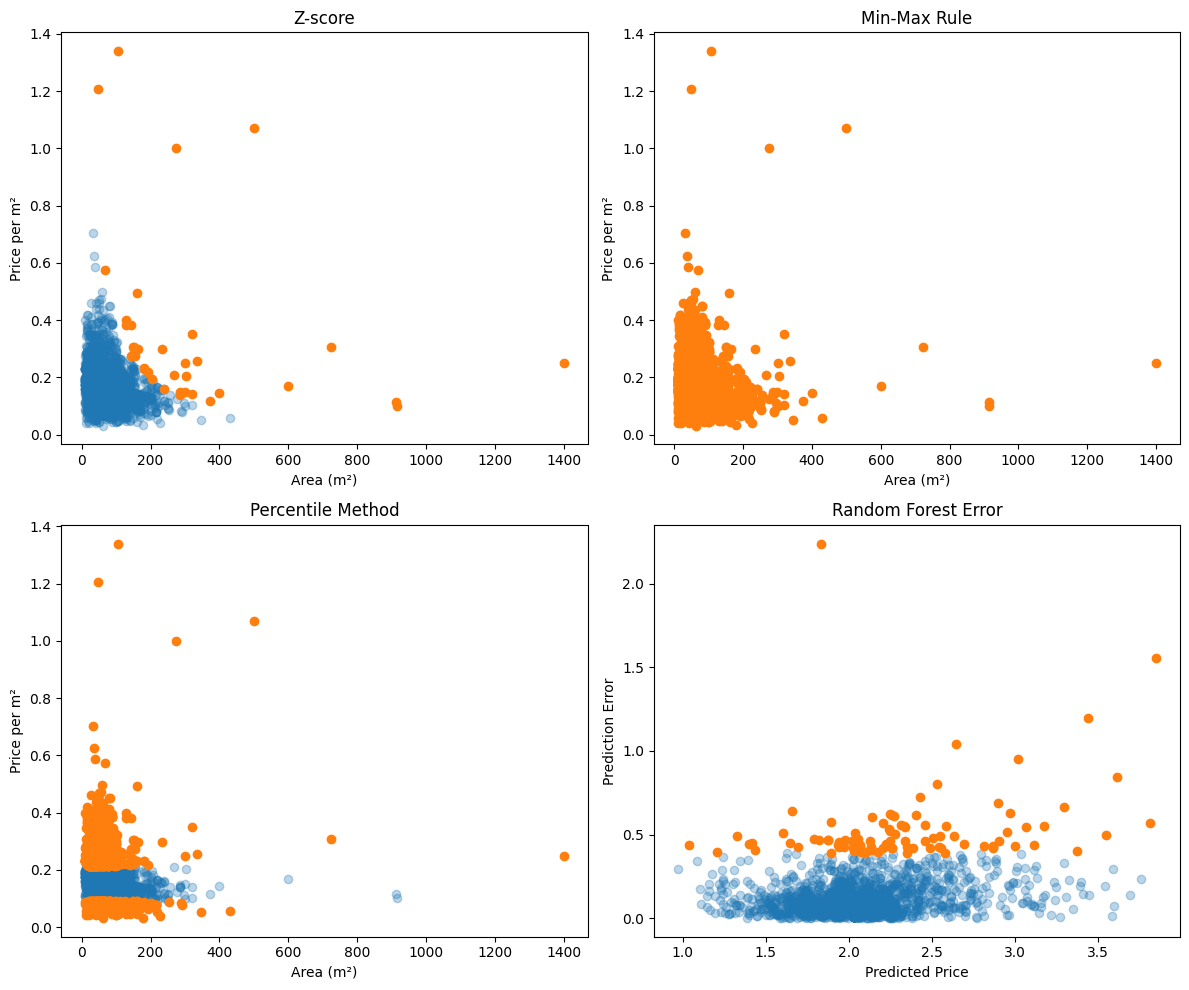

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12,10))

# 1️⃣ Z-score
normal = pdf[pdf["anomaly_zscore"] == False]
anomaly = pdf[pdf["anomaly_zscore"] == True]

axes[0,0].scatter(normal["dien_tich"], normal["price_m2"], alpha=0.3)
axes[0,0].scatter(anomaly["dien_tich"], anomaly["price_m2"])
axes[0,0].set_title("Z-score")
axes[0,0].set_xlabel("Area (m²)")
axes[0,0].set_ylabel("Price per m²")

# 2️⃣ Min-Max
normal = pdf[pdf["anomaly_minmax"] == False]
anomaly = pdf[pdf["anomaly_minmax"] == True]

axes[0,1].scatter(normal["dien_tich"], normal["price_m2"], alpha=0.3)
axes[0,1].scatter(anomaly["dien_tich"], anomaly["price_m2"])
axes[0,1].set_title("Min-Max Rule")
axes[0,1].set_xlabel("Area (m²)")
axes[0,1].set_ylabel("Price per m²")

# 3️⃣ Percentile
normal = pdf[pdf["anomaly_percentile"] == False]
anomaly = pdf[pdf["anomaly_percentile"] == True]

axes[1,0].scatter(normal["dien_tich"], normal["price_m2"], alpha=0.3)
axes[1,0].scatter(anomaly["dien_tich"], anomaly["price_m2"])
axes[1,0].set_title("Percentile Method")
axes[1,0].set_xlabel("Area (m²)")
axes[1,0].set_ylabel("Price per m²")

# 4️⃣ Random Forest Error
normal = pdf_rf[pdf_rf["anomaly"] == 0]
anomaly = pdf_rf[pdf_rf["anomaly"] == 1]

axes[1,1].scatter(normal["prediction"], normal["error"], alpha=0.3)
axes[1,1].scatter(anomaly["prediction"], anomaly["error"])
axes[1,1].set_title("Random Forest Error")
axes[1,1].set_xlabel("Predicted Price")
axes[1,1].set_ylabel("Prediction Error")

plt.tight_layout()
plt.show()

AnomalyScore=0.4×Residual+0.2×MinMax+0.2×Percentile+0.2×IsolationForest


In [23]:
from pyspark.sql.functions import col

# gộp kết quả Random Forest vào df_res
df_res = df_res.join(
    rf_anomaly.select("error","anomaly"),
    how="left"
)

# chuyển boolean -> số
df_res = df_res.withColumn(
    "z_score_flag",
    col("anomaly_zscore").cast("int")
)

df_res = df_res.withColumn(
    "minmax_flag",
    col("anomaly_minmax").cast("int")
)

df_res = df_res.withColumn(
    "percentile_flag",
    col("anomaly_percentile").cast("int")
)

df_res = df_res.withColumn(
    "rf_flag",
    col("anomaly").cast("int")
)

# tính anomaly score
df_res = df_res.withColumn(
    "anomaly_score",
    0.2*col("z_score_flag") +
    0.2*col("minmax_flag") +
    0.2*col("percentile_flag") +
    0.4*col("rf_flag")
)

df_res.select(
    "gia_ban",
    "price_m2",
    "anomaly_score",
    "z_score_flag",
    "minmax_flag",
    "percentile_flag",
    "rf_flag"
).show()

+-------+-------------------+------------------+------------+-----------+---------------+-------+
|gia_ban|           price_m2|     anomaly_score|z_score_flag|minmax_flag|percentile_flag|rf_flag|
+-------+-------------------+------------------+------------+-----------+---------------+-------+
|   3.85|0.10694444444444445|0.6000000000000001|           0|          1|              0|      1|
|   3.85|0.10694444444444445|               0.2|           0|          1|              0|      0|
|   3.85|0.10694444444444445|               0.2|           0|          1|              0|      0|
|   3.85|0.10694444444444445|0.6000000000000001|           0|          1|              0|      1|
|   3.85|0.10694444444444445|0.6000000000000001|           0|          1|              0|      1|
|   3.85|0.10694444444444445|               0.2|           0|          1|              0|      0|
|   3.85|0.10694444444444445|               0.2|           0|          1|              0|      0|
|   3.85|0.106944444

In [26]:
from pyspark.sql.functions import when, col

df_res.withColumn(
    "type",
    when(col("anomaly_final")==1,"Abnormal").otherwise("Normal")
).groupBy("type").count().show()

+--------+--------+
|    type|   count|
+--------+--------+
|Abnormal|  814837|
|  Normal|12264776|
+--------+--------+



In [27]:
total = df_res.count()

df_res.groupBy("anomaly_final").count()\
.withColumn("percent", col("count")/total*100)\
.show()

+-------------+--------+-----------------+
|anomaly_final|   count|          percent|
+-------------+--------+-----------------+
|            1|  814837|6.229824995586643|
|            0|12264776|93.77017500441336|
+-------------+--------+-----------------+



In [38]:
from pyspark.sql.functions import col, exp, abs

# chuyển prediction từ log về giá thật
df_res = df_res.withColumn(
    "predicted_price",
    exp(col("prediction")) - 1
)

# tính sai số giá thật
df_res = df_res.withColumn(
    "prediction_error_real",
    abs(col("gia_ban") - col("predicted_price"))
)

In [39]:
from pyspark.sql.functions import col

top10_anomaly = df_res.filter(
    col("anomaly_final") == 1
).orderBy(
    col("anomaly_score").desc()
).limit(10)